# Week 8 - Notebook 3: Unsupervised Learning

**Course**: Introduction to Scientific Programming (CNC-UC)  
**Topic**: Clustering and Dimensionality Reduction

---

## Learning Objectives

By the end of this notebook, you will:
- Understand unsupervised learning and its applications
- Implement clustering algorithms (K-Means, Hierarchical, DBSCAN)
- Apply dimensionality reduction (PCA, t-SNE)
- Visualize high-dimensional data
- Evaluate clustering quality
- Apply unsupervised methods to neuroscience data

## 1. Setup and Data Loading

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits, load_iris, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, 
    adjusted_rand_score, normalized_mutual_info_score
)
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist

# Set random seed
np.random.seed(42)

# Configure plotting
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Introduction to Clustering

**Clustering** groups similar data points together without predefined labels.

**Applications in Neuroscience**:
- Identifying neuron subtypes from electrophysiology
- Segmenting brain regions from imaging data
- Finding patterns in behavioral data
- Grouping patients by symptom profiles

### 2.1 Create Synthetic Data for Demonstration

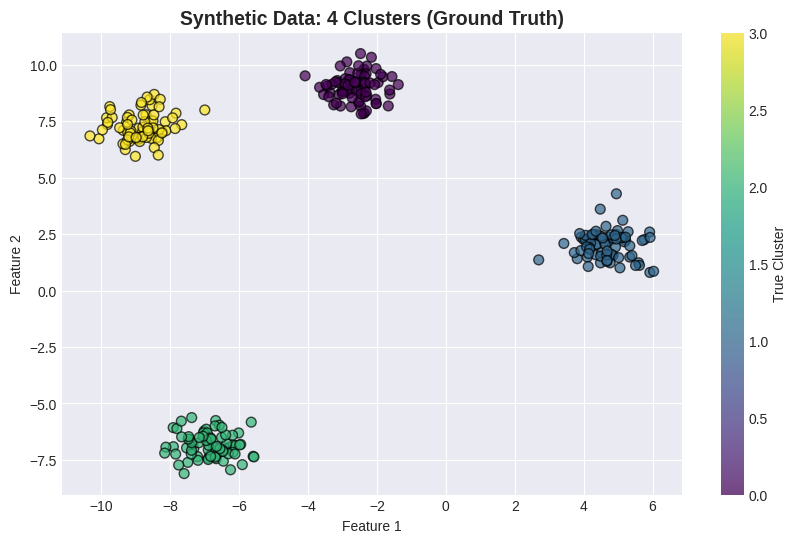

Data shape: (300, 2)
Number of true clusters: 4


In [2]:
# Create synthetic data with clear clusters
X_blobs, y_blobs_true = make_blobs(
    n_samples=300, 
    centers=4, 
    n_features=2,
    cluster_std=0.60, 
    random_state=42
)

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], 
           c=y_blobs_true, cmap='viridis', 
           s=50, edgecolors='black', alpha=0.7)
plt.title('Synthetic Data: 4 Clusters (Ground Truth)', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='True Cluster')
plt.show()

print(f"Data shape: {X_blobs.shape}")
print(f"Number of true clusters: {len(np.unique(y_blobs_true))}")

## 3. K-Means Clustering

**K-Means** partitions data into K clusters by minimizing within-cluster variance.

**Algorithm**:
1. Randomly initialize K cluster centers
2. Assign each point to nearest center
3. Recalculate centers as mean of assigned points
4. Repeat steps 2-3 until convergence

**Key Properties**:
- Fast and scalable
- Must specify K in advance
- Assumes spherical clusters
- Sensitive to initialization

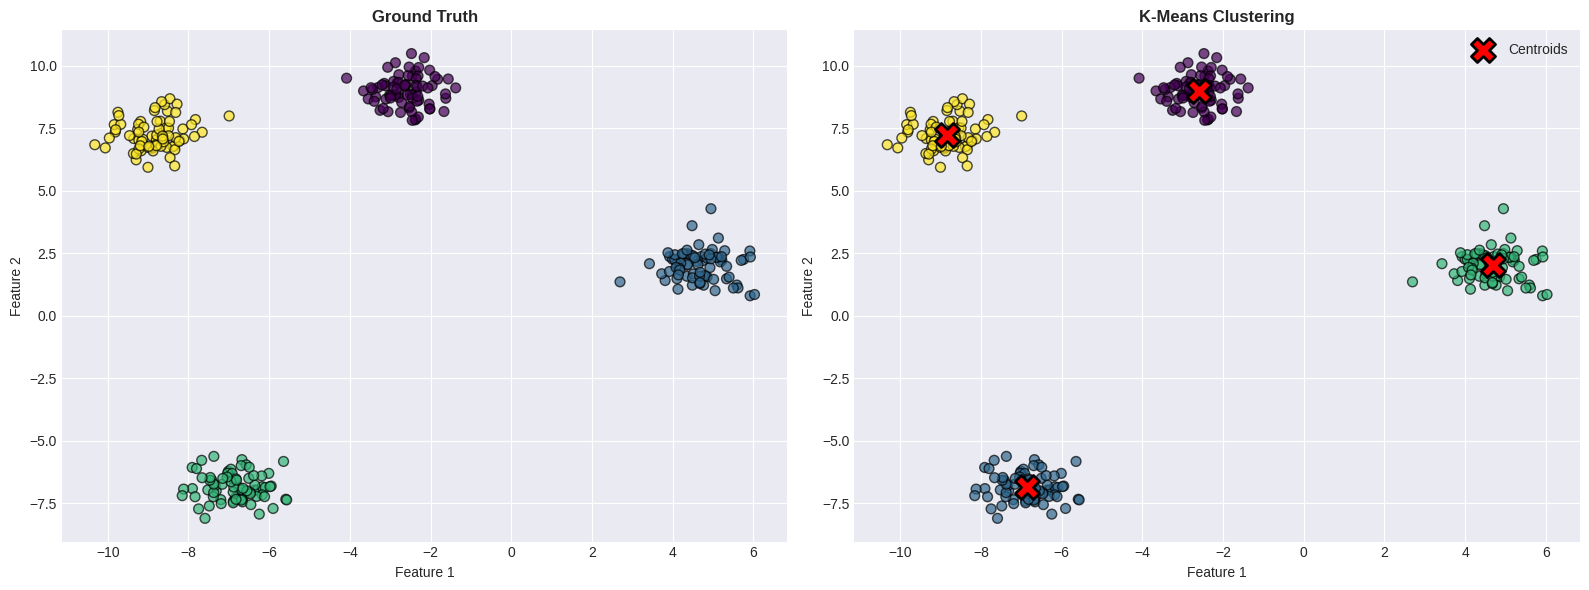

K-Means cluster centers:
[[-2.60516878  8.99280115]
 [-6.85126211 -6.85031833]
 [ 4.68687447  2.01434593]
 [-8.83456141  7.24430734]]

Inertia (within-cluster sum of squares): 203.89


In [3]:
# Apply K-Means with correct number of clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_blobs)

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ground truth
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], 
               c=y_blobs_true, cmap='viridis', 
               s=50, edgecolors='black', alpha=0.7)
axes[0].set_title('Ground Truth', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')

# K-Means results
axes[1].scatter(X_blobs[:, 0], X_blobs[:, 1], 
               c=y_kmeans, cmap='viridis', 
               s=50, edgecolors='black', alpha=0.7)
axes[1].scatter(kmeans.cluster_centers_[:, 0], 
               kmeans.cluster_centers_[:, 1],
               marker='X', s=300, c='red', 
               edgecolors='black', linewidths=2,
               label='Centroids')
axes[1].set_title('K-Means Clustering', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Feature 1')
axes[1].set_ylabel('Feature 2')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"K-Means cluster centers:\n{kmeans.cluster_centers_}")
print(f"\nInertia (within-cluster sum of squares): {kmeans.inertia_:.2f}")

### 3.1 The Elbow Method

**Problem**: How do we choose K?

**Elbow Method**: Plot inertia vs K and look for the "elbow" point where improvement slows.

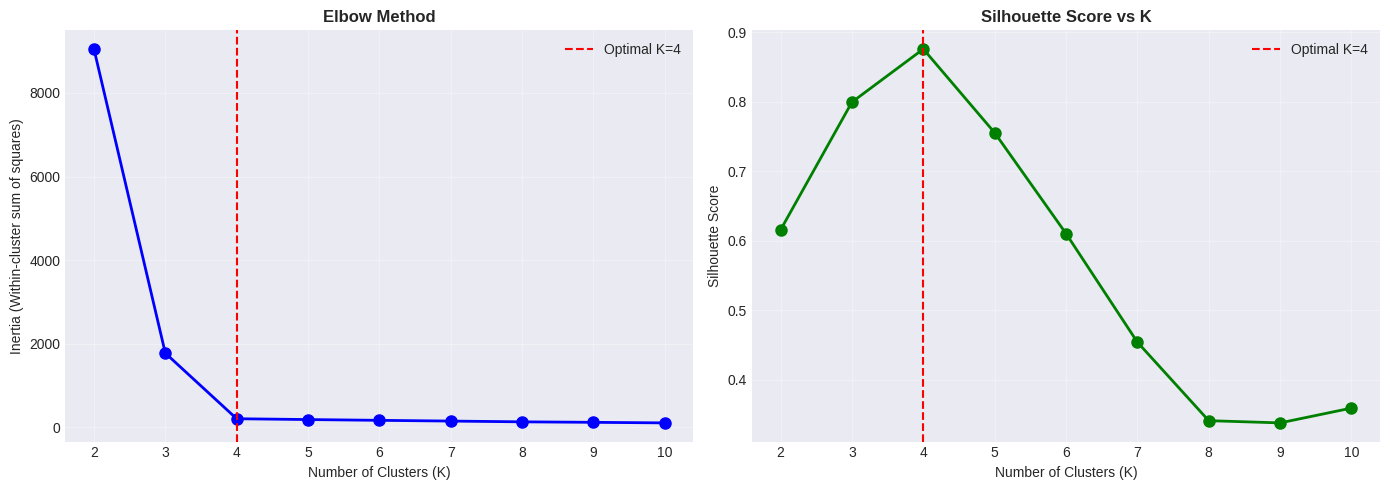


Interpretation:
- Elbow: Look for 'bend' in the curve (K=4 here)
- Silhouette: Higher is better (range -1 to 1)
- Best K by silhouette: 4


In [4]:
# Try different values of K
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_k.fit(X_blobs)
    inertias.append(kmeans_k.inertia_)
    silhouette_scores.append(silhouette_score(X_blobs, kmeans_k.labels_))

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Inertia (Elbow method)
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=4, color='red', linestyle='--', label='Optimal K=4')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-cluster sum of squares)')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Silhouette score
axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=4, color='red', linestyle='--', label='Optimal K=4')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("- Elbow: Look for 'bend' in the curve (K=4 here)")
print("- Silhouette: Higher is better (range -1 to 1)")
print(f"- Best K by silhouette: {k_range[np.argmax(silhouette_scores)]}")

## 4. Hierarchical Clustering

**Hierarchical Clustering** builds a tree (dendrogram) of clusters.

**Two Approaches**:
- **Agglomerative** (bottom-up): Start with individual points, merge similar clusters
- **Divisive** (top-down): Start with one cluster, recursively split

**Advantages**:
- Don't need to specify K in advance
- Provides hierarchy of clusters
- Deterministic (no random initialization)

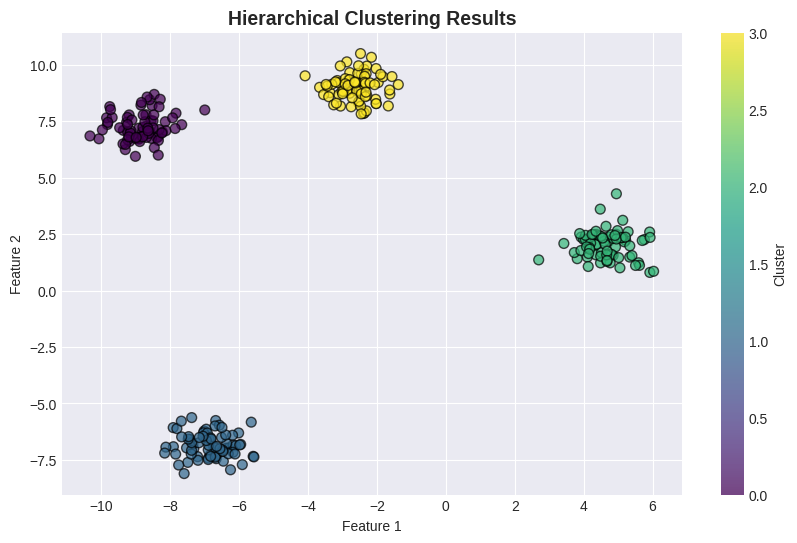

In [5]:
# Apply hierarchical clustering
hier_clustering = AgglomerativeClustering(n_clusters=4, linkage='ward')
y_hier = hier_clustering.fit_predict(X_blobs)

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], 
           c=y_hier, cmap='viridis', 
           s=50, edgecolors='black', alpha=0.7)
plt.title('Hierarchical Clustering Results', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Cluster')
plt.show()

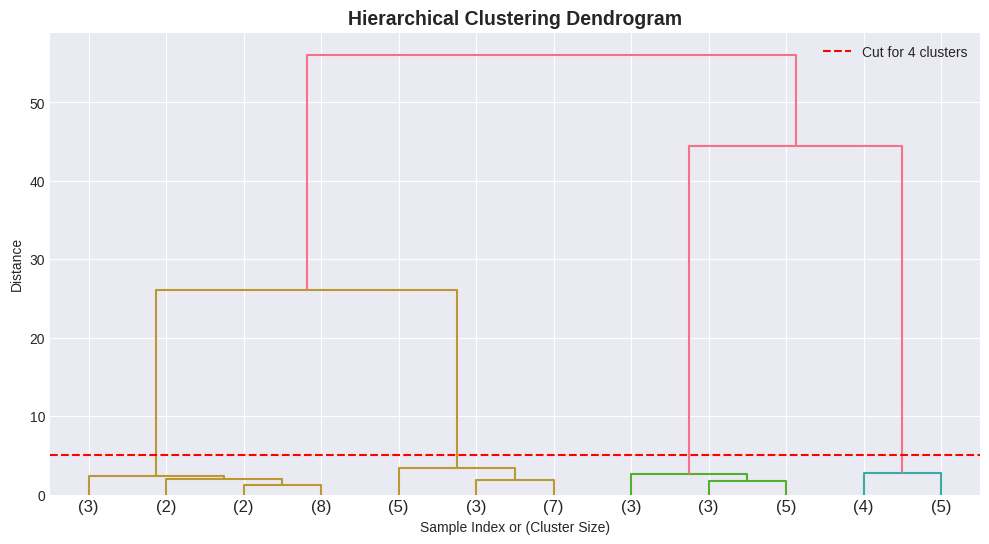


Dendrogram Interpretation:
- Height: Dissimilarity between clusters being merged
- Cut horizontally to get desired number of clusters
- Longer vertical lines = more distinct clusters


In [6]:
# Create dendrogram (only use subset for clarity)
n_samples_dendro = 50
X_subset = X_blobs[:n_samples_dendro]
linkage_matrix = linkage(X_subset, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linkage_matrix, 
          truncate_mode='lastp',
          p=12,
          show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram', fontsize=14, fontweight='bold')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance')
plt.axhline(y=5, color='red', linestyle='--', label='Cut for 4 clusters')
plt.legend()
plt.show()

print("\nDendrogram Interpretation:")
print("- Height: Dissimilarity between clusters being merged")
print("- Cut horizontally to get desired number of clusters")
print("- Longer vertical lines = more distinct clusters")

## 5. DBSCAN: Density-Based Clustering

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) finds clusters based on density.

**Key Concepts**:
- **Core points**: Have at least `min_samples` neighbors within `eps` distance
- **Border points**: Within `eps` of a core point but not core themselves
- **Noise points**: Neither core nor border (labeled as -1)

**Advantages**:
- Can find arbitrarily shaped clusters
- Identifies outliers
- Don't need to specify number of clusters

**Disadvantages**:
- Sensitive to parameters (eps, min_samples)
- Struggles with varying density clusters

Number of clusters found: 4
Number of noise points: 2


/tmp/ipykernel_11126/3110404161.py:28: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(X_blobs[mask, 0], X_blobs[mask, 1],


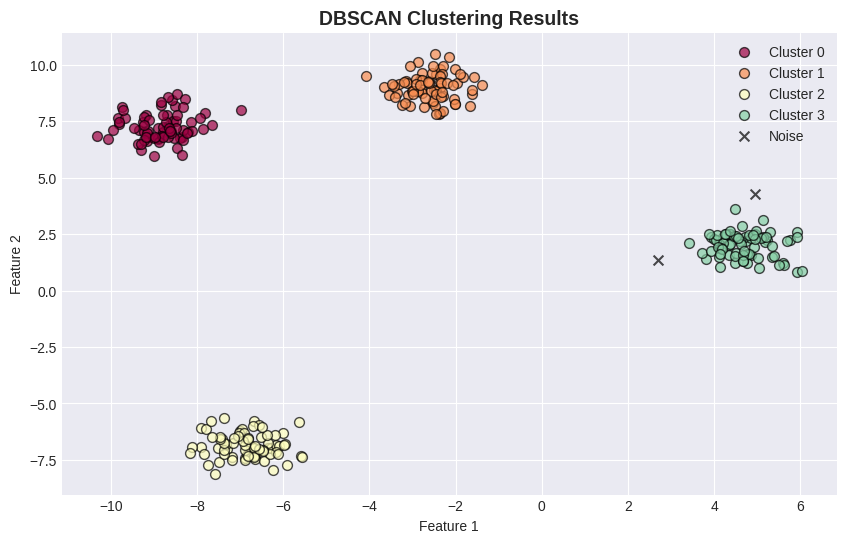

In [7]:
# Apply DBSCAN
dbscan = DBSCAN(eps=0.9, min_samples=5)
y_dbscan = dbscan.fit_predict(X_blobs)

# Count clusters and noise
n_clusters_dbscan = len(set(y_dbscan)) - (1 if -1 in y_dbscan else 0)
n_noise = list(y_dbscan).count(-1)

print(f"Number of clusters found: {n_clusters_dbscan}")
print(f"Number of noise points: {n_noise}")

# Visualize
plt.figure(figsize=(10, 6))
unique_labels = set(y_dbscan)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for label, color in zip(unique_labels, colors):
    if label == -1:
        # Noise points in black
        color = 'black'
        marker = 'x'
        label_text = 'Noise'
    else:
        marker = 'o'
        label_text = f'Cluster {label}'
    
    mask = y_dbscan == label
    plt.scatter(X_blobs[mask, 0], X_blobs[mask, 1],
               c=[color], marker=marker, s=50, 
               edgecolors='black', alpha=0.7,
               label=label_text)

plt.title('DBSCAN Clustering Results', fontsize=14, fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

## 6. Clustering Evaluation Metrics

### Internal Metrics (no ground truth needed):
- **Silhouette Score**: Measures how similar points are to their own cluster vs other clusters (-1 to 1, higher is better)
- **Davies-Bouldin Index**: Average similarity between clusters (lower is better)

### External Metrics (require ground truth):
- **Adjusted Rand Index**: Similarity between predicted and true clusters (0 to 1, higher is better)
- **Normalized Mutual Information**: Shared information between clusterings (0 to 1, higher is better)

In [8]:
# Compare clustering methods
clustering_results = {
    'K-Means': y_kmeans,
    'Hierarchical': y_hier,
    'DBSCAN': y_dbscan
}

metrics_results = []
for name, labels in clustering_results.items():
    # Skip DBSCAN noise points for some metrics
    mask = labels != -1
    X_no_noise = X_blobs[mask]
    labels_no_noise = labels[mask]
    y_true_no_noise = y_blobs_true[mask]
    
    # Calculate metrics
    silhouette = silhouette_score(X_no_noise, labels_no_noise)
    davies_bouldin = davies_bouldin_score(X_no_noise, labels_no_noise)
    ari = adjusted_rand_score(y_true_no_noise, labels_no_noise)
    nmi = normalized_mutual_info_score(y_true_no_noise, labels_no_noise)
    
    metrics_results.append({
        'Method': name,
        'Silhouette': silhouette,
        'Davies-Bouldin': davies_bouldin,
        'Adj. Rand Index': ari,
        'NMI': nmi
    })

metrics_df = pd.DataFrame(metrics_results)
print("\nClustering Quality Metrics:\n")
print(metrics_df.to_string(index=False))

print("\n" + "="*60)
print("Metric Interpretation:")
print("="*60)
print("Silhouette Score:      Higher is better (range: -1 to 1)")
print("Davies-Bouldin Index:  Lower is better (>0)")
print("Adjusted Rand Index:   Higher is better (range: 0 to 1)")
print("NMI:                   Higher is better (range: 0 to 1)")
print("="*60)


Clustering Quality Metrics:

      Method  Silhouette  Davies-Bouldin  Adj. Rand Index  NMI
     K-Means    0.875647        0.173674              1.0  1.0
Hierarchical    0.875647        0.173674              1.0  1.0
      DBSCAN    0.877333        0.172646              1.0  1.0

Metric Interpretation:
Silhouette Score:      Higher is better (range: -1 to 1)
Davies-Bouldin Index:  Lower is better (>0)
Adjusted Rand Index:   Higher is better (range: 0 to 1)
NMI:                   Higher is better (range: 0 to 1)


## 7. Dimensionality Reduction: PCA

**Principal Component Analysis (PCA)** finds orthogonal directions of maximum variance.

**How it Works**:
1. Center the data (subtract mean)
2. Compute covariance matrix
3. Find eigenvectors (principal components)
4. Project data onto top K components

**Use Cases**:
- Visualization of high-dimensional data
- Noise reduction
- Feature extraction
- Speeding up algorithms

Digits dataset shape: (1797, 64)
Number of features: 64
Number of classes: 10


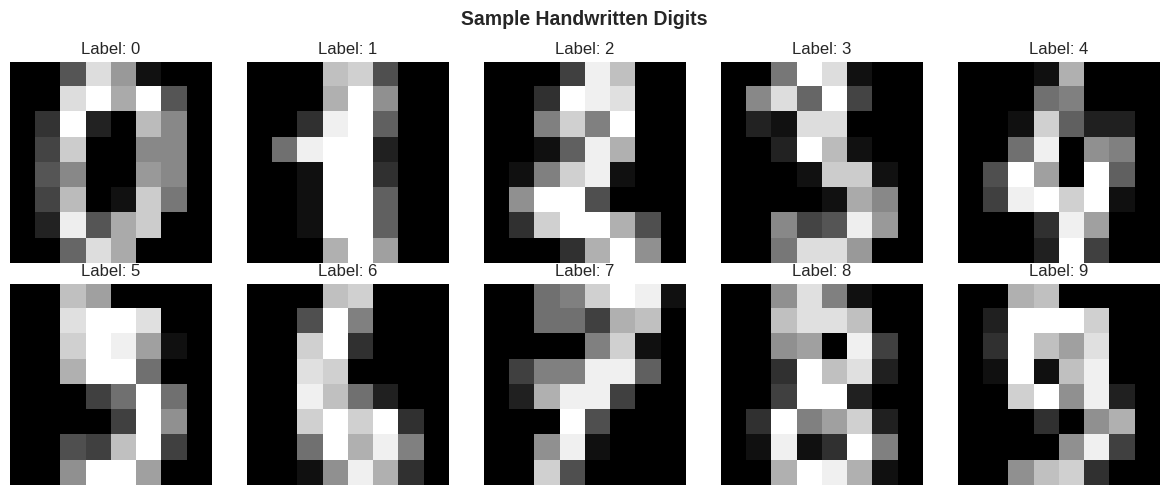

In [9]:
# Load high-dimensional dataset: Handwritten digits (64 features)
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

print(f"Digits dataset shape: {X_digits.shape}")
print(f"Number of features: {X_digits.shape[1]}")
print(f"Number of classes: {len(np.unique(y_digits))}")

# Visualize some digits
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for idx, ax in enumerate(axes.ravel()):
    ax.imshow(X_digits[idx].reshape(8, 8), cmap='gray')
    ax.set_title(f'Label: {y_digits[idx]}')
    ax.axis('off')
plt.suptitle('Sample Handwritten Digits', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

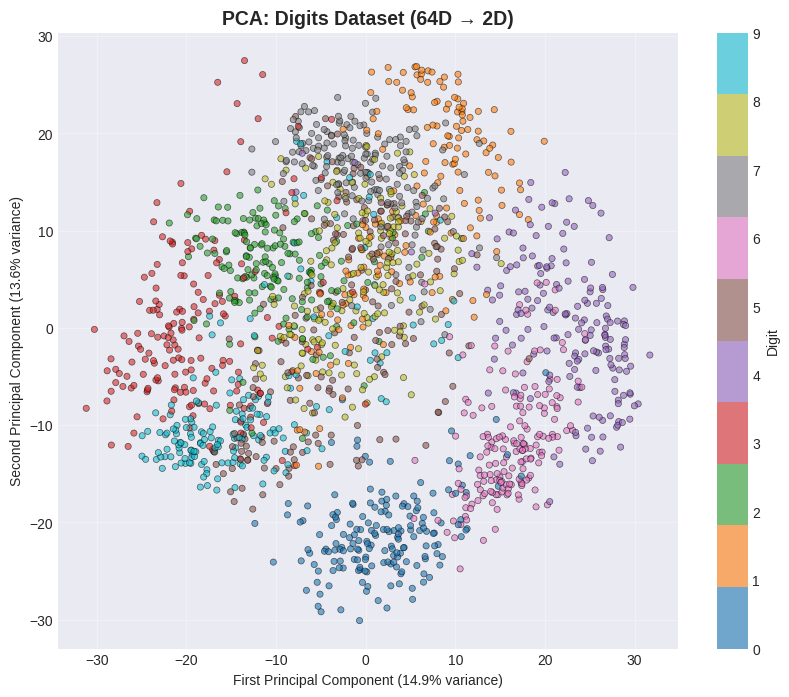


Variance explained by 2 components: 28.51%
Component 1: 14.89%
Component 2: 13.62%


In [10]:
# Apply PCA to reduce to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_digits)

# Visualize
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                     c=y_digits, cmap='tab10', 
                     s=20, alpha=0.6, edgecolors='black', linewidths=0.5)
plt.colorbar(scatter, label='Digit')
plt.xlabel(f'First Principal Component ({pca.explained_variance_ratio_[0]:.1%} variance)')
plt.ylabel(f'Second Principal Component ({pca.explained_variance_ratio_[1]:.1%} variance)')
plt.title('PCA: Digits Dataset (64D → 2D)', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.show()

print(f"\nVariance explained by 2 components: {pca.explained_variance_ratio_.sum():.2%}")
print(f"Component 1: {pca.explained_variance_ratio_[0]:.2%}")
print(f"Component 2: {pca.explained_variance_ratio_[1]:.2%}")

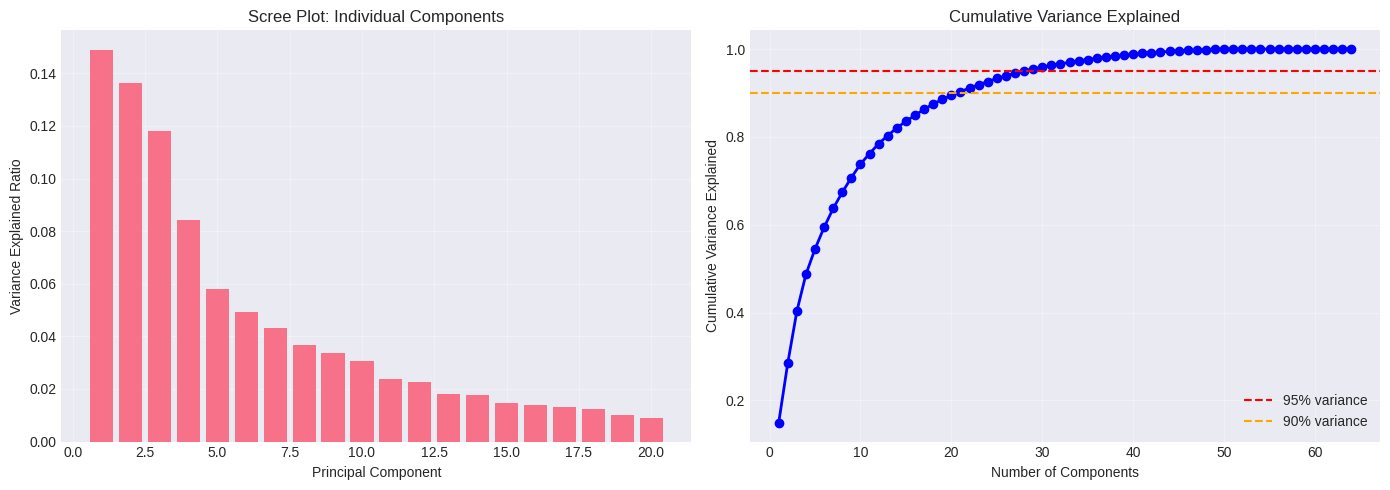


Components needed for 95% variance: 29 (out of 64)
Dimensionality reduction: 64 → 29 (45.3%)


In [11]:
# Scree plot: How many components do we need?
pca_full = PCA(random_state=42)
pca_full.fit(X_digits)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual variance explained
axes[0].bar(range(1, 21), pca_full.explained_variance_ratio_[:20])
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained Ratio')
axes[0].set_title('Scree Plot: Individual Components')
axes[0].grid(alpha=0.3)

# Cumulative variance explained
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
axes[1].plot(range(1, len(cumsum)+1), cumsum, 'bo-', linewidth=2)
axes[1].axhline(y=0.95, color='r', linestyle='--', label='95% variance')
axes[1].axhline(y=0.90, color='orange', linestyle='--', label='90% variance')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Find number of components for 95% variance
n_components_95 = np.argmax(cumsum >= 0.95) + 1
print(f"\nComponents needed for 95% variance: {n_components_95} (out of {X_digits.shape[1]})")
print(f"Dimensionality reduction: {X_digits.shape[1]} → {n_components_95} ({n_components_95/X_digits.shape[1]:.1%})")

## 8. t-SNE: Non-Linear Dimensionality Reduction

**t-SNE** (t-Distributed Stochastic Neighbor Embedding) preserves local structure.

**Key Differences from PCA**:
- **Non-linear**: Can capture complex relationships
- **Local focus**: Preserves neighborhood structure
- **Visualization only**: Not for general dimensionality reduction
- **Slower**: Computationally expensive

**Important**:
- Distances between clusters are not meaningful
- Different runs give different results
- Great for visualization, not for preprocessing

In [12]:
# Apply t-SNE (use subset for speed)
n_samples_tsne = 1000
X_digits_subset = X_digits[:n_samples_tsne]
y_digits_subset = y_digits[:n_samples_tsne]

# First reduce with PCA (recommended preprocessing)
pca_pre = PCA(n_components=50, random_state=42)
X_pca_pre = pca_pre.fit_transform(X_digits_subset)

# Then apply t-SNE
print("Running t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_pca_pre)

print("✓ t-SNE complete")

Running t-SNE (this may take a minute)...
✓ t-SNE complete


/tmp/ipykernel_11126/1939708376.py:27: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


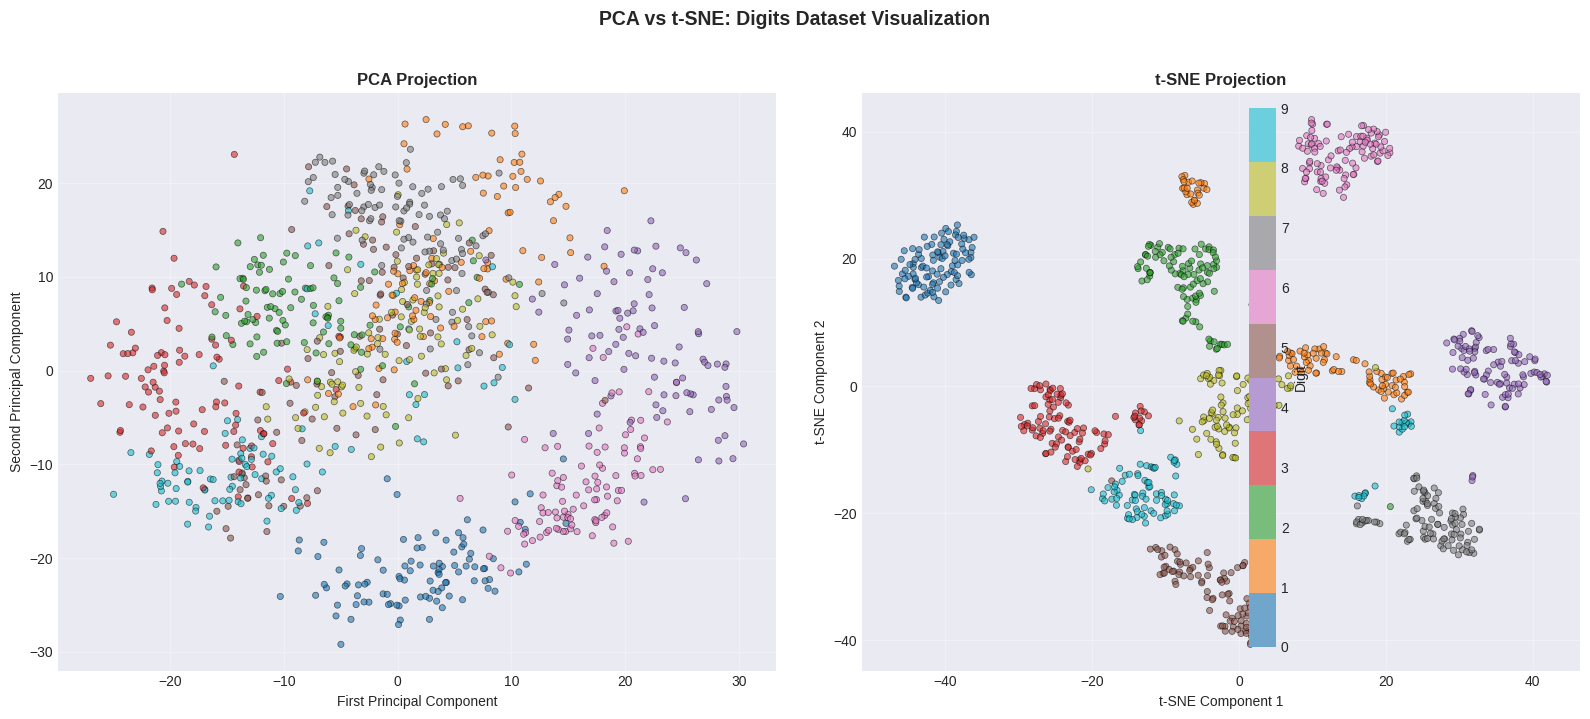


Observations:
- t-SNE shows better cluster separation
- PCA captures global structure
- t-SNE preserves local neighborhoods


In [13]:
# Compare PCA vs t-SNE
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# PCA
scatter1 = axes[0].scatter(X_pca[:n_samples_tsne, 0], X_pca[:n_samples_tsne, 1],
                          c=y_digits_subset, cmap='tab10',
                          s=20, alpha=0.6, edgecolors='black', linewidths=0.5)
axes[0].set_xlabel('First Principal Component')
axes[0].set_ylabel('Second Principal Component')
axes[0].set_title('PCA Projection', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# t-SNE
scatter2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                          c=y_digits_subset, cmap='tab10',
                          s=20, alpha=0.6, edgecolors='black', linewidths=0.5)
axes[1].set_xlabel('t-SNE Component 1')
axes[1].set_ylabel('t-SNE Component 2')
axes[1].set_title('t-SNE Projection', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

# Shared colorbar
cbar = plt.colorbar(scatter2, ax=axes, label='Digit')

plt.suptitle('PCA vs t-SNE: Digits Dataset Visualization', 
            fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nObservations:")
print("- t-SNE shows better cluster separation")
print("- PCA captures global structure")
print("- t-SNE preserves local neighborhoods")

## 9. Real Data Example

Let's use the Iris dataset as an example.

**Scenario**: Classify flower species based on petal and sepal measurements

In [14]:
# Load Iris dataset
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names_iris = iris.feature_names

print("Dataset: Iris (analogy for neuron types)")
print(f"Shape: {X_iris.shape}")
print(f"Features: {feature_names_iris}")
print(f"Classes: {iris.target_names}")
print("\nAnalogy: Different species = Different neuron types")

# Scale data
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

Dataset: Iris (analogy for neuron types)
Shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']

Analogy: Different species = Different neuron types


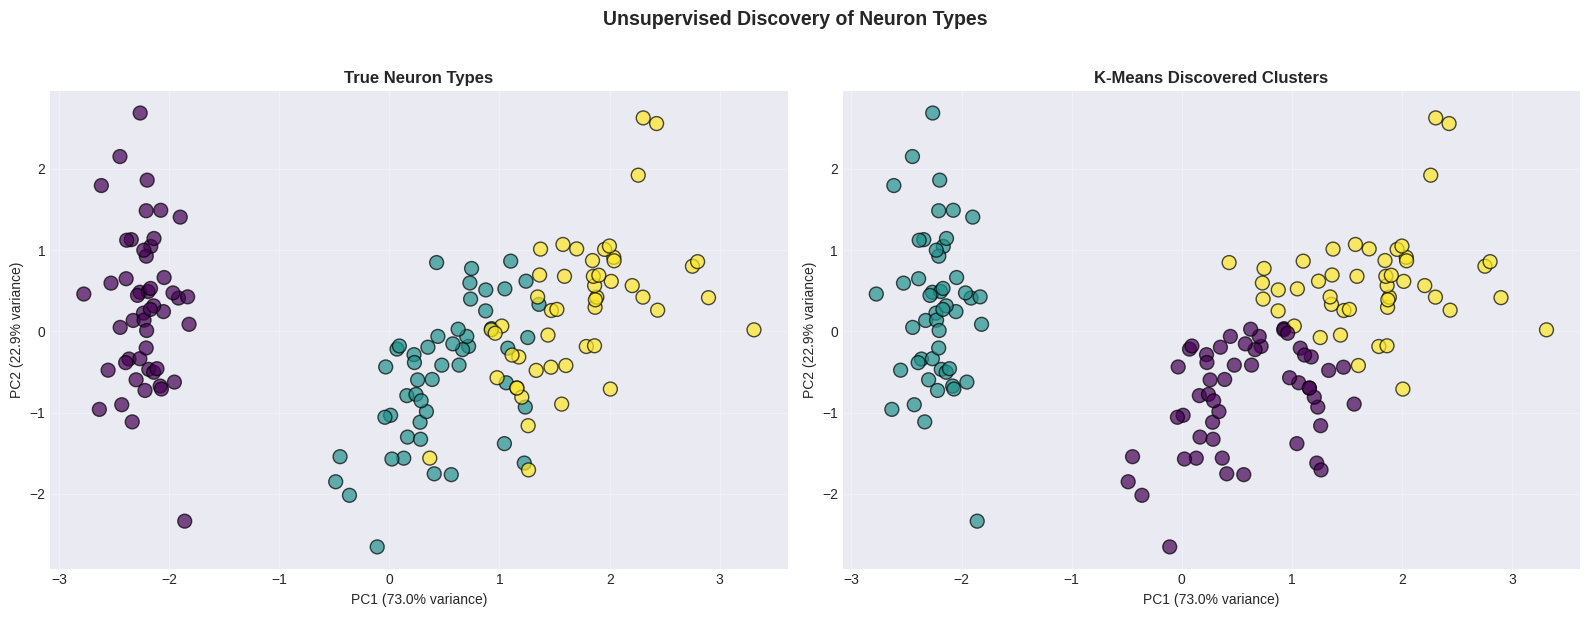


Clustering Performance:
Adjusted Rand Index: 0.620 (agreement with true labels)
Normalized Mutual Info: 0.659
Silhouette Score: 0.460 (cluster quality)

K-Means successfully discovered 3 neuron types!


In [15]:
# Apply unsupervised methods (pretend we don't know true labels)
kmeans_iris = KMeans(n_clusters=3, random_state=42, n_init=10)
y_kmeans_iris = kmeans_iris.fit_predict(X_iris_scaled)

pca_iris = PCA(n_components=2, random_state=42)
X_iris_pca = pca_iris.fit_transform(X_iris_scaled)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# True labels
scatter1 = axes[0].scatter(X_iris_pca[:, 0], X_iris_pca[:, 1],
                          c=y_iris, cmap='viridis',
                          s=100, edgecolors='black', alpha=0.7)
axes[0].set_xlabel(f'PC1 ({pca_iris.explained_variance_ratio_[0]:.1%} variance)')
axes[0].set_ylabel(f'PC2 ({pca_iris.explained_variance_ratio_[1]:.1%} variance)')
axes[0].set_title('True Neuron Types', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# K-Means discovered clusters
scatter2 = axes[1].scatter(X_iris_pca[:, 0], X_iris_pca[:, 1],
                          c=y_kmeans_iris, cmap='viridis',
                          s=100, edgecolors='black', alpha=0.7)
axes[1].set_xlabel(f'PC1 ({pca_iris.explained_variance_ratio_[0]:.1%} variance)')
axes[1].set_ylabel(f'PC2 ({pca_iris.explained_variance_ratio_[1]:.1%} variance)')
axes[1].set_title('K-Means Discovered Clusters', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.suptitle('Unsupervised Discovery of Neuron Types', 
            fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Evaluate clustering
ari_iris = adjusted_rand_score(y_iris, y_kmeans_iris)
nmi_iris = normalized_mutual_info_score(y_iris, y_kmeans_iris)
silhouette_iris = silhouette_score(X_iris_scaled, y_kmeans_iris)

print(f"\nClustering Performance:")
print(f"Adjusted Rand Index: {ari_iris:.3f} (agreement with true labels)")
print(f"Normalized Mutual Info: {nmi_iris:.3f}")
print(f"Silhouette Score: {silhouette_iris:.3f} (cluster quality)")
print(f"\nK-Means successfully discovered {np.unique(y_kmeans_iris).size} neuron types!")

## 10. Key Takeaways

### Clustering Algorithm Selection:

**Use K-Means when**:
- You know the number of clusters
- Clusters are roughly spherical
- Speed is important
- Data is large

**Use Hierarchical Clustering when**:
- You want a hierarchy of clusters
- Number of clusters is unknown
- Dataset is small to medium
- Deterministic results needed

**Use DBSCAN when**:
- Clusters have arbitrary shapes
- Outlier detection is important
- Number of clusters is unknown
- Density-based structure expected

### Dimensionality Reduction:

**Use PCA when**:
- Need linear transformation
- Want to explain variance
- Need for downstream algorithms
- Interpretability matters

**Use t-SNE when**:
- Visualization is the goal
- Non-linear structure important
- Dataset not too large
- Don't need inverse transform

## 11. Practice Exercises

1. **Parameter Sensitivity**: Try different `eps` and `min_samples` values in DBSCAN. How does it affect clustering?

2. **Optimal K**: Use the elbow method to find optimal K for the Iris dataset. Compare with the true number of classes.

3. **PCA Reconstruction**: Project digits to 20 components with PCA, then reconstruct. Compare original vs reconstructed images.

4. **t-SNE Perplexity**: Run t-SNE with different perplexity values (5, 30, 50). How do visualizations change?

5. **Your Own Data**: Apply clustering and dimensionality reduction to your datasets!